# =============================================================================
# PROJETO: MNIST Digit Classifier - Análise Preditiva Multiclasse
# AUTOR: Guillermo Jose Salas Avila
# DATA: 10/09/2026
# DESCRIÇÃO: Pipeline completo de Machine Learning para classificação de 
#            dígitos manuscritos usando o dataset MNIST.
#            Modelos: Random Forest, KNN e MLP (scikit-learn)
# =============================================================================

# 0- Importação de bibliotecas

In [2]:
# =============================================================================
# PROJETO: MNIST Digit Classifier - Análise Preditiva Multiclasse
# AUTOR: Guillermo Jose Salas Avila
# DATA: 10/09/2026
# DESCRIÇÃO: Pipeline completo de ML para classificação de dígitos manuscritos
# MODELOS: Random Forest, KNN e MLP (100% scikit-learn)
# =============================================================================

# -----------------------------------------------------------------------------
# BIBLIOTECAS CORE
# -----------------------------------------------------------------------------
import numpy as np              # Operações matemáticas e arrays
import pandas as pd             # Manipulação de dados tabulares
import matplotlib.pyplot as plt # Visualizações
import seaborn as sns           # Visualizações estatísticas
import time                     # Medição de tempo
import os                       # Manipulação de pastas
import warnings
warnings.filterwarnings('ignore')

# -----------------------------------------------------------------------------
# MACHINE LEARNING (Scikit-Learn)
# -----------------------------------------------------------------------------
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# -----------------------------------------------------------------------------
# PROCESSAMENTO DE IMAGENS (Desafio C)
# -----------------------------------------------------------------------------
from PIL import Image, ImageOps

# -----------------------------------------------------------------------------
# CONFIGURAÇÕES
# -----------------------------------------------------------------------------
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Criar pasta de resultados
os.makedirs('results', exist_ok=True)

print("=" * 80)
print("🧠 MNIST - ANÁLISE PREDITIVA MULTICLASSE")
print("=" * 80)
print("✅ Importações realizadas com sucesso!")
print("📌 Modelos: Random Forest, KNN, MLP (scikit-learn)")
print("=" * 80)

🧠 MNIST - ANÁLISE PREDITIVA MULTICLASSE
✅ Importações realizadas com sucesso!
📌 Modelos: Random Forest, KNN, MLP (scikit-learn)


# 1- Carregamento e Análise Exploratória (EDA)

In [3]:
# =============================================================================
# ETAPA 1: CARREGAMENTO E ANÁLISE EXPLORATÓRIA (EDA)
# =============================================================================

print("\n" + "=" * 80)
print("📥 ETAPA 1: CARREGAMENTO DO DATASET MNIST")
print("=" * 80)

# Baixar o dataset MNIST via fetch_openml
print("\n📥 Baixando o dataset MNIST...")
print("(Pode levar alguns minutos na primeira execução)")

mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
print("✅ Dataset MNIST baixado com sucesso!")

# Separar dados (X) e rótulos (y)
X, y = mnist.data, mnist.target.astype(int)

# Análise da dimensionalidade
print("\n📊 DIMENSIONALIDADE:")
print("-" * 50)
print(f"X shape: {X.shape}  → {X.shape[0]} imagens × {X.shape[1]} pixels")
print(f"y shape: {y.shape}  → {y.shape[0]} rótulos")
print(f"Classes: {np.unique(y)}")

# Verificar valores dos pixels
print(f"\n🎨 VALORES DOS PIXELS:")
print(f"  Mínimo: {X.min()}  |  Máximo: {X.max()}  |  Média: {X.mean():.2f}")
print(f"  Escala: 0 (preto) a 255 (branco)")


📥 ETAPA 1: CARREGAMENTO DO DATASET MNIST

📥 Baixando o dataset MNIST...
(Pode levar alguns minutos na primeira execução)
✅ Dataset MNIST baixado com sucesso!

📊 DIMENSIONALIDADE:
--------------------------------------------------
X shape: (70000, 784)  → 70000 imagens × 784 pixels
y shape: (70000,)  → 70000 rótulos
Classes: [0 1 2 3 4 5 6 7 8 9]

🎨 VALORES DOS PIXELS:
  Mínimo: 0  |  Máximo: 255  |  Média: 33.39
  Escala: 0 (preto) a 255 (branco)



📊 DISTRIBUIÇÃO DAS CLASSES:
------------------------------------------------------------
Dígito 0:  6903 imagens ( 9.86%) ████
Dígito 1:  7877 imagens (11.25%) █████
Dígito 2:  6990 imagens ( 9.99%) ████
Dígito 3:  7141 imagens (10.20%) █████
Dígito 4:  6824 imagens ( 9.75%) ████
Dígito 5:  6313 imagens ( 9.02%) ████
Dígito 6:  6876 imagens ( 9.82%) ████
Dígito 7:  7293 imagens (10.42%) █████
Dígito 8:  6825 imagens ( 9.75%) ████
Dígito 9:  6958 imagens ( 9.94%) ████
------------------------------------------------------------
Total: 70000  |  Razão maior/menor: 1.25
✅ Dataset BALANCEADO


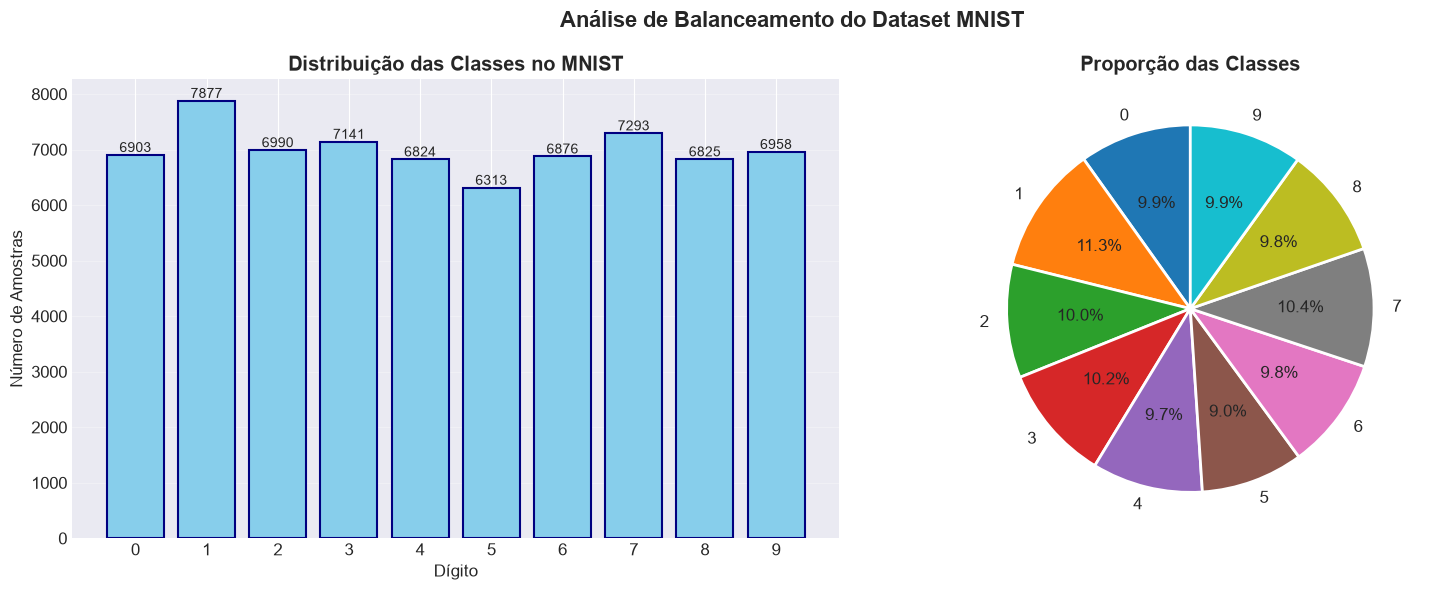

In [4]:
# -----------------------------------------------------------------------------
# DISTRIBUIÇÃO DAS CLASSES (BALANCEAMENTO)
# -----------------------------------------------------------------------------

print("\n📊 DISTRIBUIÇÃO DAS CLASSES:")
print("-" * 60)

# Contar imagens por dígito
unique, counts = np.unique(y, return_counts=True)
total = len(y)
min_count, max_count = counts.min(), counts.max()

for digit, count in zip(unique, counts):
    percentage = (count / total) * 100
    bar = "█" * int(percentage / 2)
    print(f"Dígito {digit}: {count:5d} imagens ({percentage:5.2f}%) {bar}")

print("-" * 60)
print(f"Total: {total}  |  Razão maior/menor: {max_count/min_count:.2f}")
print(f"✅ Dataset BALANCEADO")

# -----------------------------------------------------------------------------
# VISUALIZAÇÃO
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de barras
bars = axes[0].bar(unique, counts, color='skyblue', edgecolor='navy', linewidth=1.5)
axes[0].set_xlabel('Dígito'); axes[0].set_ylabel('Número de Amostras')
axes[0].set_title('Distribuição das Classes no MNIST', fontweight='bold')
axes[0].set_xticks(range(10)); axes[0].grid(axis='y', alpha=0.3)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                 f'{count}', ha='center', va='bottom', fontsize=10)

# Gráfico de pizza
colors = plt.cm.tab10(np.linspace(0, 1, 10))
axes[1].pie(counts, labels=unique, autopct='%1.1f%%', startangle=90,
            colors=colors, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporção das Classes', fontweight='bold')

plt.suptitle('Análise de Balanceamento do Dataset MNIST', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('results/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

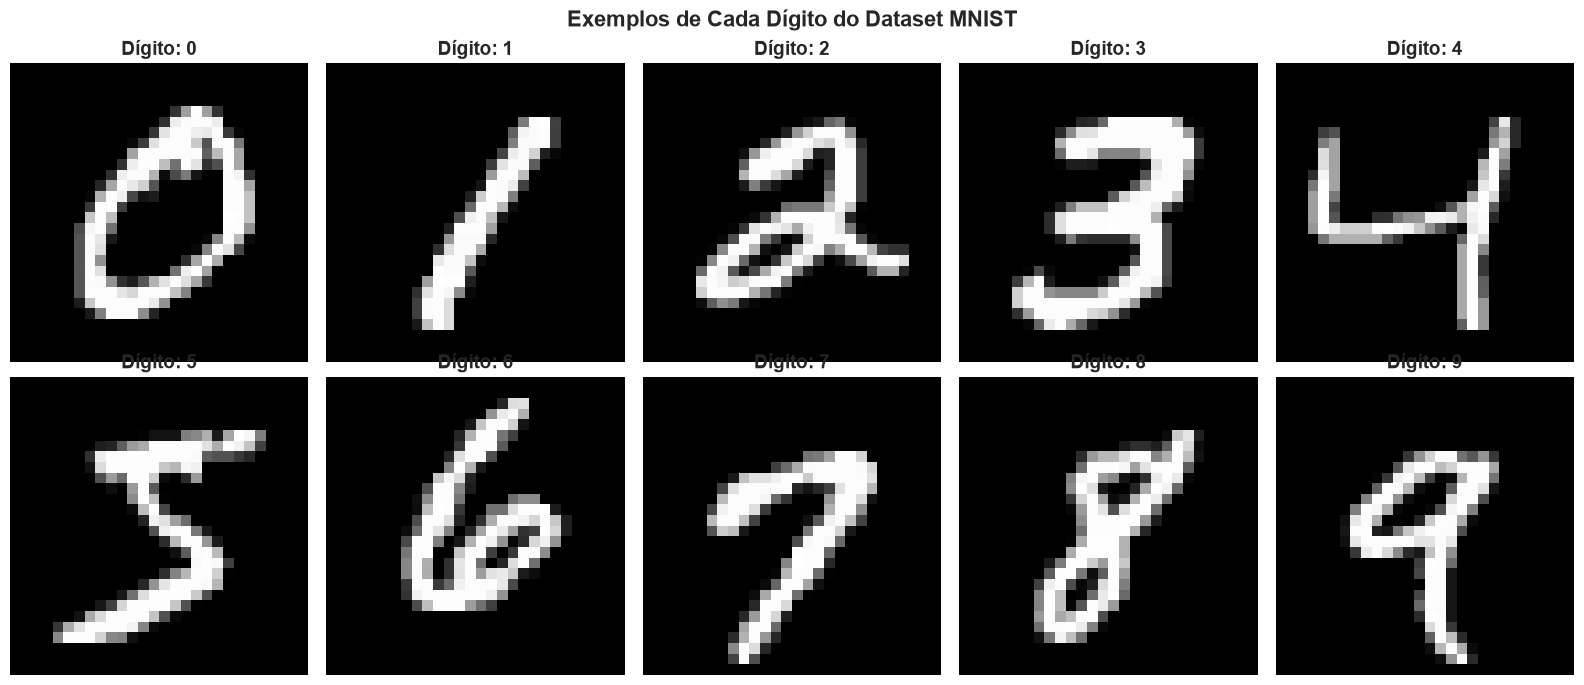


📖 INTERPRETAÇÃO DOS DADOS:

1. ESCALA DE INTENSIDADE (0 a 255):
   • 0 = Preto (fundo) | 255 = Branco (traço)

2. REPRESENTAÇÃO 2D (28 × 28 pixels):
   • Cada imagem é uma matriz de 28 linhas × 28 colunas

3. REPRESENTAÇÃO VETORIAL (784 features):
   • Cada imagem vira um vetor de 784 posições
   • Permite uso de algoritmos de ML tradicionais



In [5]:
# -----------------------------------------------------------------------------
# GRADE VISUAL DE EXEMPLOS (2 × 5)
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.ravel()

for digit in range(10):
    idx = np.where(y == digit)[0][0]
    image = X[idx].reshape(28, 28)
    axes[digit].imshow(image, cmap='gray')
    axes[digit].set_title(f'Dígito: {digit}', fontsize=14, fontweight='bold')
    axes[digit].axis('off')

plt.suptitle('Exemplos de Cada Dígito do Dataset MNIST', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('results/digit_grid.png', dpi=300, bbox_inches='tight')
plt.show()

# -----------------------------------------------------------------------------
# INTERPRETAÇÃO DA ESTRUTURA
# -----------------------------------------------------------------------------

print("""
📖 INTERPRETAÇÃO DOS DADOS:

1. ESCALA DE INTENSIDADE (0 a 255):
   • 0 = Preto (fundo) | 255 = Branco (traço)

2. REPRESENTAÇÃO 2D (28 × 28 pixels):
   • Cada imagem é uma matriz de 28 linhas × 28 colunas

3. REPRESENTAÇÃO VETORIAL (784 features):
   • Cada imagem vira um vetor de 784 posições
   • Permite uso de algoritmos de ML tradicionais
""")

# 2- Pré-processamento e Divisão dos Dados

In [6]:
# =============================================================================
# ETAPA 2: PRÉ-PROCESSAMENTO E DIVISÃO DOS DADOS
# =============================================================================

print("\n" + "=" * 80)
print("⚙️ ETAPA 2: PRÉ-PROCESSAMENTO")
print("=" * 80)

# Divisão estratificada: 70% treino / 10% validação / 20% teste
print("\n📊 Realizando divisão estratificada...")

# Passo 1: 80% (treino+val) e 20% (teste)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Passo 2: 87.5% (treino) e 12.5% (val) do subconjunto → 70% e 10% do total
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.125,
    random_state=RANDOM_STATE, stratify=y_train_val
)

# Verificação dos tamanhos
print(f"\n📏 TAMANHO DOS CONJUNTOS:")
print("-" * 50)
print(f"Treino:    {X_train.shape[0]:5d} imagens ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validação: {X_val.shape[0]:5d} imagens ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Teste:     {X_test.shape[0]:5d} imagens ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verificar estratificação
print(f"\n🔍 Proporção das classes:")
print("-" * 50)
for digit in range(10):
    tr = (y_train == digit).sum() / len(y_train) * 100
    vl = (y_val == digit).sum() / len(y_val) * 100
    ts = (y_test == digit).sum() / len(y_test) * 100
    print(f"Dígito {digit}: Treino {tr:.2f}% | Val {vl:.2f}% | Teste {ts:.2f}%")
print("✅ Estratificação OK")


⚙️ ETAPA 2: PRÉ-PROCESSAMENTO

📊 Realizando divisão estratificada...

📏 TAMANHO DOS CONJUNTOS:
--------------------------------------------------
Treino:    49000 imagens (70.0%)
Validação:  7000 imagens (10.0%)
Teste:     14000 imagens (20.0%)

🔍 Proporção das classes:
--------------------------------------------------
Dígito 0: Treino 9.86% | Val 9.86% | Teste 9.86%
Dígito 1: Treino 11.25% | Val 11.26% | Teste 11.25%
Dígito 2: Treino 9.99% | Val 9.99% | Teste 9.99%
Dígito 3: Treino 10.20% | Val 10.20% | Teste 10.20%
Dígito 4: Treino 9.75% | Val 9.74% | Teste 9.75%
Dígito 5: Treino 9.02% | Val 9.01% | Teste 9.02%
Dígito 6: Treino 9.82% | Val 9.83% | Teste 9.82%
Dígito 7: Treino 10.42% | Val 10.41% | Teste 10.42%
Dígito 8: Treino 9.75% | Val 9.76% | Teste 9.75%
Dígito 9: Treino 9.94% | Val 9.94% | Teste 9.94%
✅ Estratificação OK


In [7]:
# -----------------------------------------------------------------------------
# NORMALIZAÇÃO DOS PIXELS PARA [0.0, 1.0]
# -----------------------------------------------------------------------------

print("\n📏 Aplicando normalização dos pixels...")

X_train_norm = X_train / 255.0
X_val_norm   = X_val / 255.0
X_test_norm  = X_test / 255.0

print(f"\n✅ NORMALIZAÇÃO APLICADA:")
print(f"Min: {X_train_norm.min():.4f} | Max: {X_train_norm.max():.4f} | Média: {X_train_norm.mean():.4f}")

# -----------------------------------------------------------------------------
# JUSTIFICATIVA
# -----------------------------------------------------------------------------

print("""
📖 POR QUE NORMALIZAR?

1. CONVERGÊNCIA DE MODELOS LINEARES:
   • Gradientes mais estáveis

2. DISTÂNCIAS MÉTRICAS (KNN):
   • Evita que features de maior magnitude dominem

3. REDES NEURAIS (MLP):
   • Acelera convergência, evita saturação

4. COMPARAÇÃO JUSTA:
   • Todos os modelos sob as mesmas condições
""")


📏 Aplicando normalização dos pixels...

✅ NORMALIZAÇÃO APLICADA:
Min: 0.0000 | Max: 1.0000 | Média: 0.1310

📖 POR QUE NORMALIZAR?

1. CONVERGÊNCIA DE MODELOS LINEARES:
   • Gradientes mais estáveis

2. DISTÂNCIAS MÉTRICAS (KNN):
   • Evita que features de maior magnitude dominem

3. REDES NEURAIS (MLP):
   • Acelera convergência, evita saturação

4. COMPARAÇÃO JUSTA:
   • Todos os modelos sob as mesmas condições



# 3- Implementação e Treinamento dos 3 Modelos

In [8]:
# =============================================================================
# ETAPA 3: IMPLEMENTAÇÃO E TREINAMENTO DOS MODELOS
# =============================================================================

print("\n" + "=" * 80)
print("🤖 ETAPA 3: TREINAMENTO DOS MODELOS")
print("=" * 80)

models = {}
train_times = {}

# -----------------------------------------------------------------------------
# MODELO 1: RANDOM FOREST
# -----------------------------------------------------------------------------
print("\n" + "=" * 60)
print("🌲 MODELO 1: RANDOM FOREST")
print("=" * 60)

rf_model = RandomForestClassifier(
    n_estimators=100,       # 100 árvores
    max_depth=20,           # profundidade máxima (evita overfitting)
    min_samples_split=10,   # mínimo de amostras para dividir nó
    random_state=RANDOM_STATE,
    n_jobs=-1               # paralelização
)

start_time = time.time()
rf_model.fit(X_train_norm, y_train)
rf_train_time = time.time() - start_time
train_times['Random Forest'] = rf_train_time

print(f"✅ Treinado em {rf_train_time:.2f} segundos")
models['Random Forest'] = rf_model


🤖 ETAPA 3: TREINAMENTO DOS MODELOS

🌲 MODELO 1: RANDOM FOREST
✅ Treinado em 7.10 segundos


In [9]:
# -----------------------------------------------------------------------------
# MODELO 2: K-NEAREST NEIGHBORS (KNN)
# -----------------------------------------------------------------------------
print("\n" + "=" * 60)
print("👥 MODELO 2: K-NEAREST NEIGHBORS (KNN)")
print("=" * 60)

knn_model = KNeighborsClassifier(
    n_neighbors=5,       # 5 vizinhos
    weights='distance',  # peso por distância
    metric='euclidean',  # distância Euclidiana
    n_jobs=-1
)

start_time = time.time()
knn_model.fit(X_train_norm, y_train)
knn_train_time = time.time() - start_time
train_times['KNN'] = knn_train_time

print(f"✅ Treinado em {knn_train_time:.2f} segundos")
models['KNN'] = knn_model


👥 MODELO 2: K-NEAREST NEIGHBORS (KNN)
✅ Treinado em 0.06 segundos



🧠 MODELO 3: REDE NEURAL MLP (scikit-learn)
✅ Treinado em 168.35 segundos
   Iterações: 46


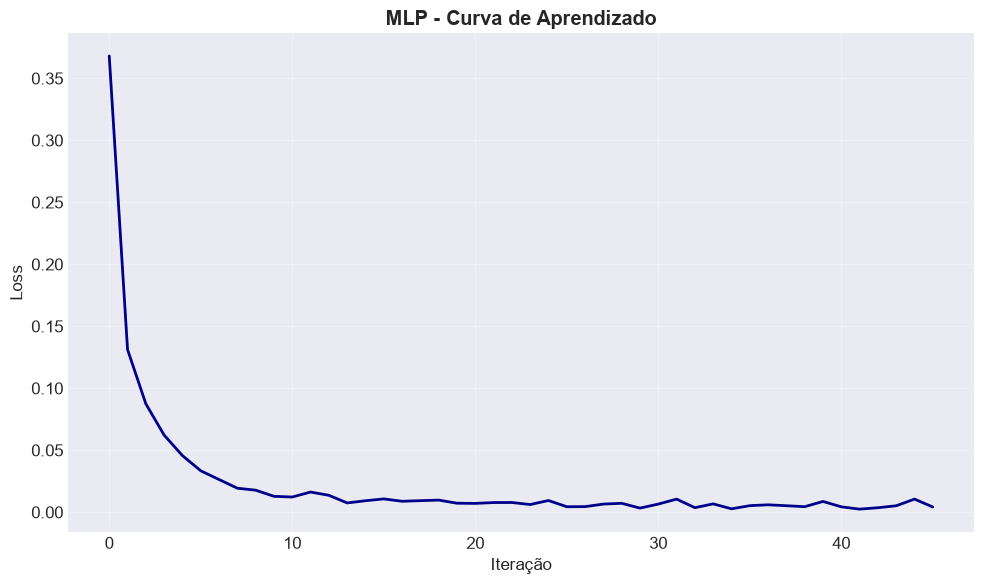


✅ TODOS OS 3 MODELOS TREINADOS!


In [10]:
# -----------------------------------------------------------------------------
# MODELO 3: REDE NEURAL MLP (scikit-learn)
# -----------------------------------------------------------------------------
print("\n" + "=" * 60)
print("🧠 MODELO 3: REDE NEURAL MLP (scikit-learn)")
print("=" * 60)

mlp_model = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),  # 3 camadas ocultas
    activation='relu',                   # função de ativação
    solver='adam',                       # otimizador adaptativo
    learning_rate_init=0.001,            # taxa de aprendizado
    max_iter=50,                         # máximo de épocas
    early_stopping=True,                 # parada antecipada
    validation_fraction=0.1,             # 10% para validação interna
    alpha=0.0001,                        # regularização L2
    random_state=RANDOM_STATE,
    verbose=False
)

start_time = time.time()
mlp_model.fit(X_train_norm, y_train)
mlp_train_time = time.time() - start_time
train_times['MLP (scikit-learn)'] = mlp_train_time

print(f"✅ Treinado em {mlp_train_time:.2f} segundos")
print(f"   Iterações: {mlp_model.n_iter_}")
models['MLP (scikit-learn)'] = mlp_model

# -----------------------------------------------------------------------------
# CURVA DE APRENDIZADO DO MLP
# -----------------------------------------------------------------------------

plt.figure(figsize=(10, 6))
plt.plot(mlp_model.loss_curve_, linewidth=2, color='darkblue')
plt.xlabel('Iteração'); plt.ylabel('Loss')
plt.title('MLP - Curva de Aprendizado', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/mlp_learning_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
print(f"✅ TODOS OS {len(models)} MODELOS TREINADOS!")
print("=" * 60)

# 4- Avaliação Comparativa

In [11]:
# =============================================================================
# ETAPA 4.1 — Função de Avaliação
# =============================================================================

print("\n" + "=" * 80)
print("📊 ETAPA 4: AVALIAÇÃO COMPARATIVA")
print("=" * 80)

def evaluate_model(model, X_test, y_test, model_name):
    """Avalia modelo e retorna métricas + matriz de confusão."""
    print(f"\n{'='*60}\n🔍 AVALIAÇÃO: {model_name}\n{'='*60}")
    
    start_time = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - start_time
    
    # Métricas
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec  = recall_score(y_test, y_pred, average='weighted')
    f1   = f1_score(y_test, y_pred, average='weighted')
    
    print(f"\n📈 MÉTRICAS:")
    print(f"  Acurácia:            {acc:.4f} ({acc*100:.2f}%)")
    print(f"  Precisão (weighted): {prec:.4f}")
    print(f"  Recall (weighted):   {rec:.4f}")
    print(f"  F1-Score (weighted): {f1:.4f}")
    print(f"  Tempo de predição:   {pred_time:.4f} s")
    
    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(10), yticklabels=range(10),
                cbar_kws={'label': 'Contagem'})
    plt.title(f'Matriz de Confusão - {model_name}', fontweight='bold')
    plt.xlabel('Predito'); plt.ylabel('Real')
    plt.tight_layout()
    safe = model_name.replace(" ", "_").replace("(", "").replace(")", "")
    plt.savefig(f'results/confusion_matrix_{safe}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Classification Report
    print(f"\n📋 Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))
    
    return {'model': model_name, 'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1, 'pred_time': pred_time,
            'cm': cm, 'y_pred': y_pred}


📊 ETAPA 4: AVALIAÇÃO COMPARATIVA



🔍 AVALIAÇÃO: Random Forest

📈 MÉTRICAS:
  Acurácia:            0.9615 (96.15%)
  Precisão (weighted): 0.9615
  Recall (weighted):   0.9615
  F1-Score (weighted): 0.9615
  Tempo de predição:   0.1950 s


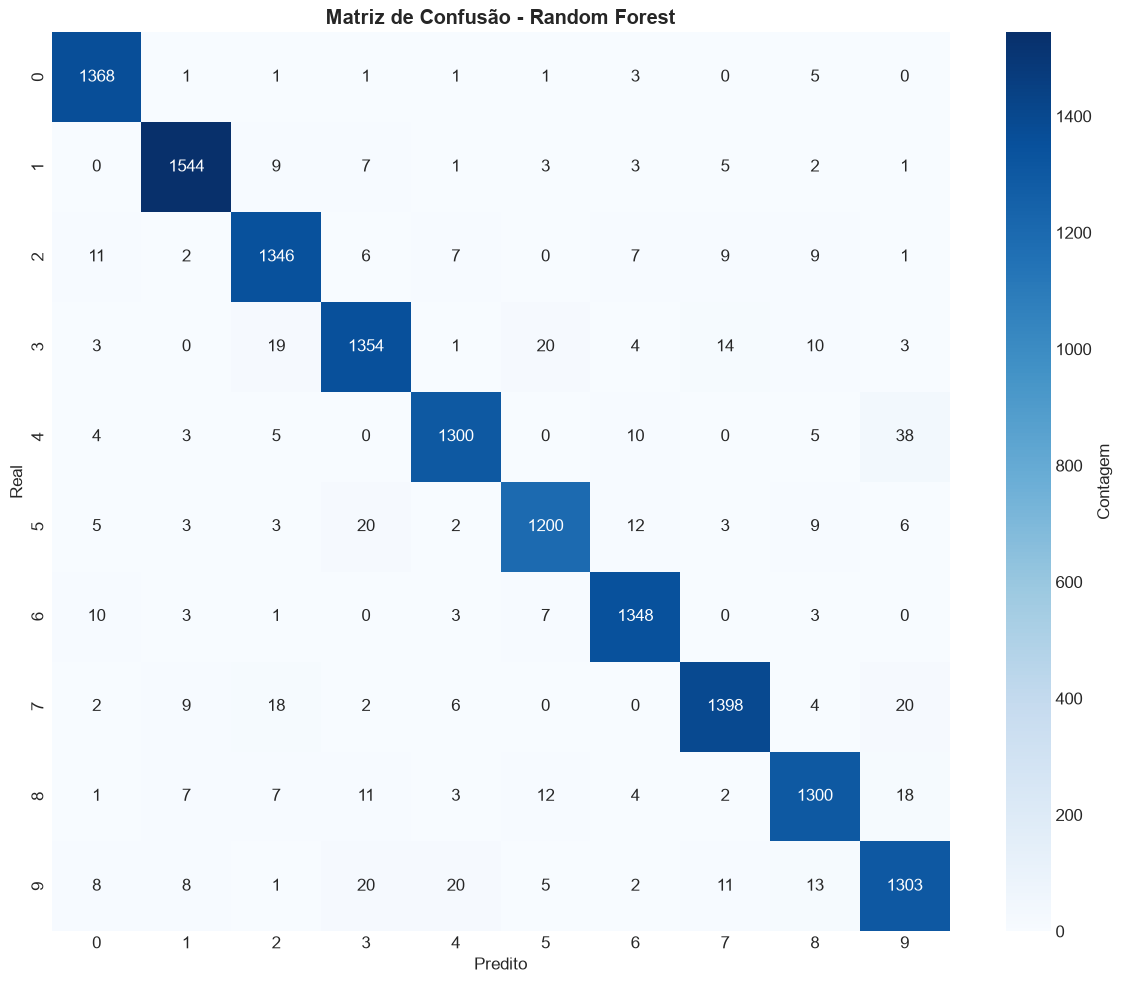


📋 Classification Report:
              precision    recall  f1-score   support

           0     0.9688    0.9906    0.9796      1381
           1     0.9772    0.9803    0.9788      1575
           2     0.9546    0.9628    0.9587      1398
           3     0.9529    0.9482    0.9505      1428
           4     0.9673    0.9524    0.9598      1365
           5     0.9615    0.9501    0.9558      1263
           6     0.9677    0.9804    0.9740      1375
           7     0.9695    0.9582    0.9638      1459
           8     0.9559    0.9524    0.9541      1365
           9     0.9374    0.9367    0.9371      1391

    accuracy                         0.9615     14000
   macro avg     0.9613    0.9612    0.9612     14000
weighted avg     0.9615    0.9615    0.9615     14000


🔍 AVALIAÇÃO: KNN

📈 MÉTRICAS:
  Acurácia:            0.9704 (97.04%)
  Precisão (weighted): 0.9707
  Recall (weighted):   0.9704
  F1-Score (weighted): 0.9703
  Tempo de predição:   13.8912 s


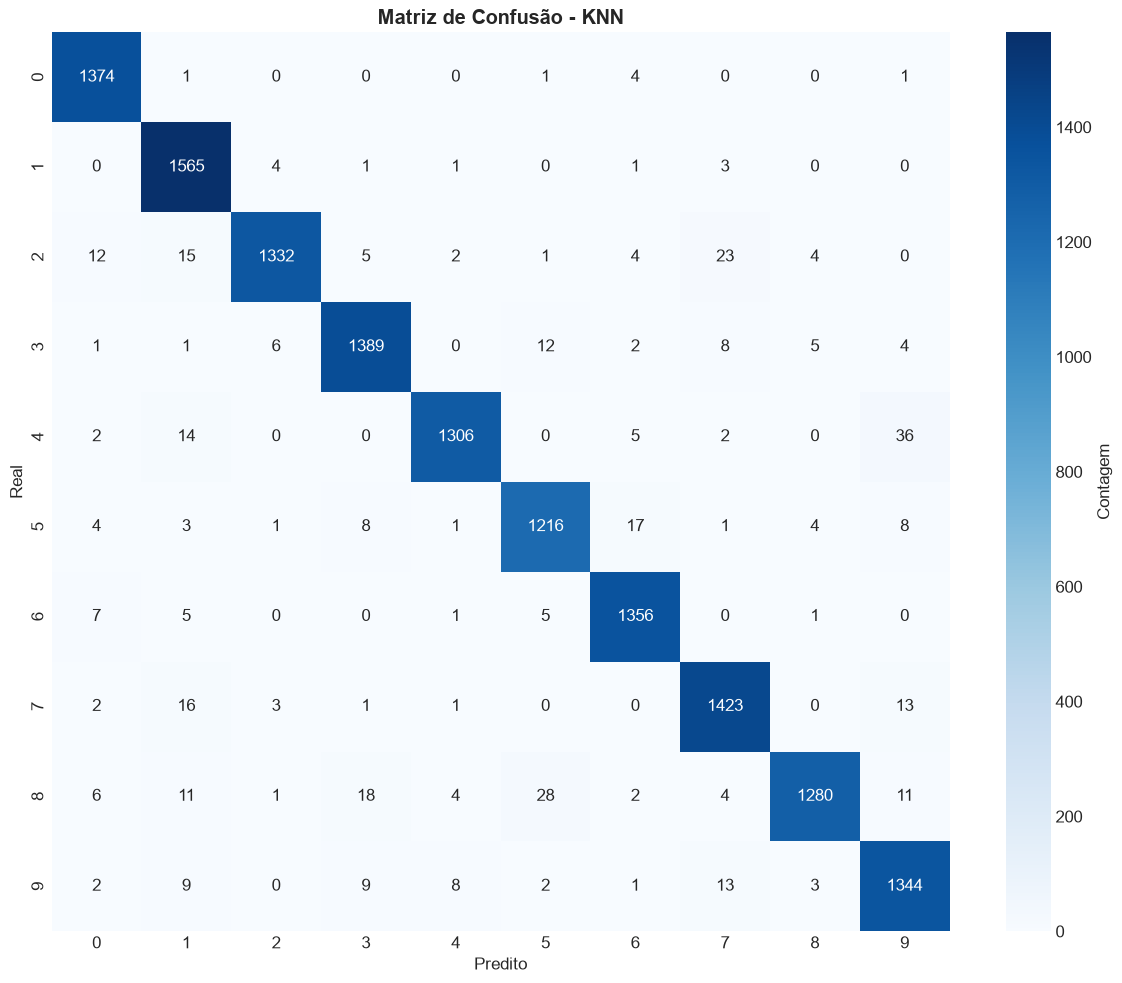


📋 Classification Report:
              precision    recall  f1-score   support

           0     0.9745    0.9949    0.9846      1381
           1     0.9543    0.9937    0.9736      1575
           2     0.9889    0.9528    0.9705      1398
           3     0.9706    0.9727    0.9717      1428
           4     0.9864    0.9568    0.9714      1365
           5     0.9613    0.9628    0.9620      1263
           6     0.9741    0.9862    0.9801      1375
           7     0.9634    0.9753    0.9693      1459
           8     0.9869    0.9377    0.9617      1365
           9     0.9485    0.9662    0.9573      1391

    accuracy                         0.9704     14000
   macro avg     0.9709    0.9699    0.9702     14000
weighted avg     0.9707    0.9704    0.9703     14000


🔍 AVALIAÇÃO: MLP (scikit-learn)

📈 MÉTRICAS:
  Acurácia:            0.9796 (97.96%)
  Precisão (weighted): 0.9797
  Recall (weighted):   0.9796
  F1-Score (weighted): 0.9796
  Tempo de predição:   0.1019 s


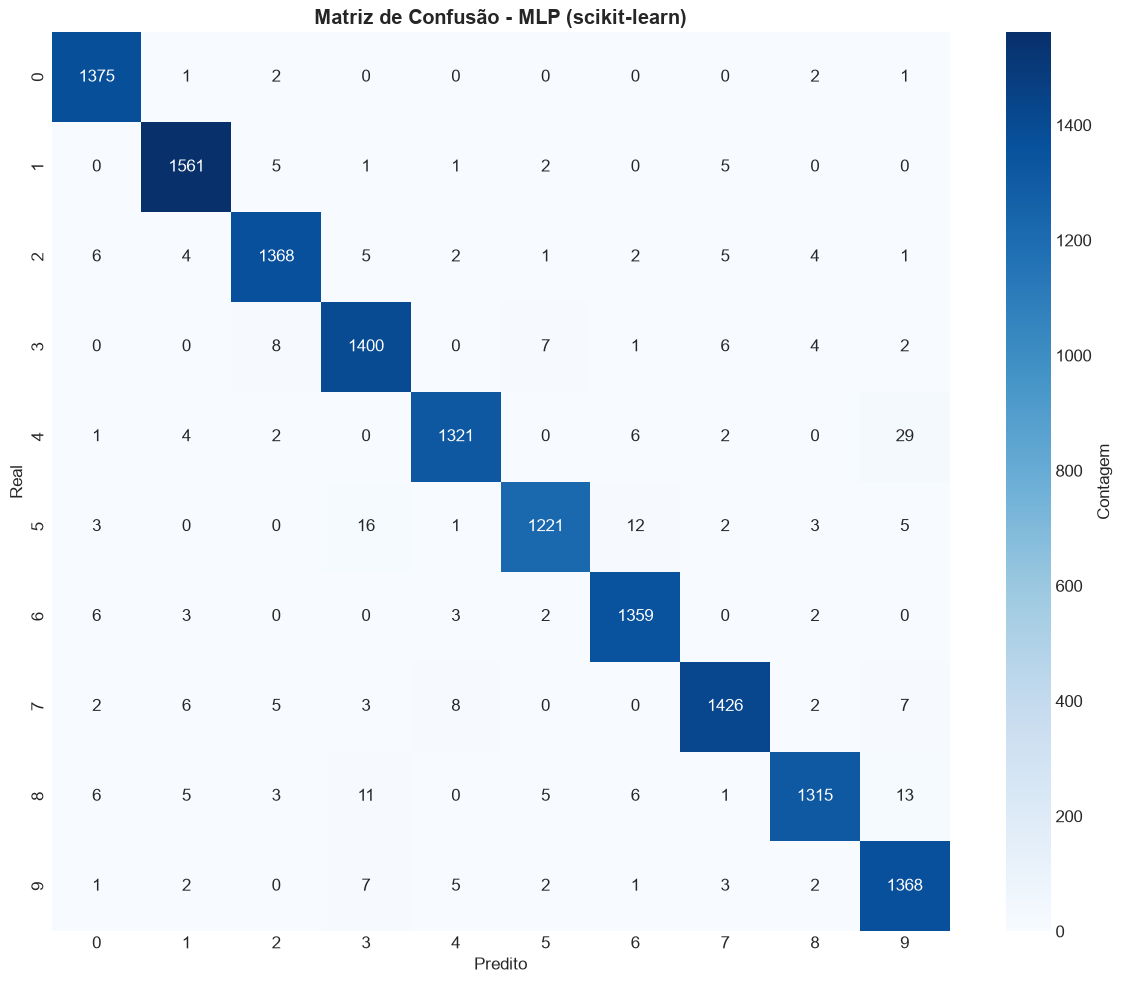


📋 Classification Report:
              precision    recall  f1-score   support

           0     0.9821    0.9957    0.9889      1381
           1     0.9842    0.9911    0.9877      1575
           2     0.9821    0.9785    0.9803      1398
           3     0.9702    0.9804    0.9753      1428
           4     0.9851    0.9678    0.9763      1365
           5     0.9847    0.9667    0.9756      1263
           6     0.9798    0.9884    0.9841      1375
           7     0.9834    0.9774    0.9804      1459
           8     0.9858    0.9634    0.9744      1365
           9     0.9593    0.9835    0.9712      1391

    accuracy                         0.9796     14000
   macro avg     0.9797    0.9793    0.9794     14000
weighted avg     0.9797    0.9796    0.9796     14000


✅ Todos os modelos avaliados!


In [12]:
# -----------------------------------------------------------------------------
# 4.2 — Avaliar Todos os Modelos
# -----------------------------------------------------------------------------

results = []
for model_name, model in models.items():
    result = evaluate_model(model, X_test_norm, y_test, model_name)
    result['train_time'] = train_times.get(model_name, 0)
    results.append(result)

print("\n✅ Todos os modelos avaliados!")

In [ ]:
# -----------------------------------------------------------------------------
# 4.3 — Tabela Comparativa
# -----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("📊 TABELA COMPARATIVA")
print("=" * 80)

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df[['model', 'accuracy', 'precision', 'recall',
                                'f1', 'train_time', 'pred_time']].round(4)
comparison_df.columns = ['Modelo', 'Acurácia', 'Precisão', 'Recall',
                          'F1-Score', 'Treino (s)', 'Predição (s)']

print("\n" + comparison_df.to_string(index=False))
comparison_df.to_csv('results/comparison_table.csv', index=False)

# Melhor modelo
best_idx = comparison_df['Acurácia'].idxmax()
print(f"\n🏆 Melhor modelo: {comparison_df.loc[best_idx, 'Modelo']}")

# -----------------------------------------------------------------------------
# GRÁFICO COMPARATIVO
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
metrics = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
x = np.arange(len(metrics)); width = 0.25
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for i, (_, row) in enumerate(comparison_df.iterrows()):
    vals = [row[m] for m in metrics]
    axes[0].bar(x + i*width, vals, width, label=row['Modelo'], color=colors[i])
axes[0].set_xticks(x + width); axes[0].set_xticklabels(metrics)
axes[0].set_ylabel('Valor'); axes[0].set_ylim(0.9, 1.0)
axes[0].set_title('Métricas por Modelo', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

for i, (_, row) in enumerate(comparison_df.iterrows()):
    axes[1].scatter(row['Treino (s)'], row['Acurácia'], s=300,
                    color=colors[i], label=row['Modelo'],
                    zorder=5, edgecolors='black', linewidth=2)
    axes[1].annotate(row['Modelo'], (row['Treino (s)'], row['Acurácia']),
                     xytext=(10, 5), textcoords='offset points', fontweight='bold')
axes[1].set_xlabel('Tempo de Treino (s)'); axes[1].set_ylabel('Acurácia')
axes[1].set_title('Trade-off: Tempo vs Acurácia', fontweight='bold')
axes[1].grid(True, alpha=0.3); axes[1].legend()

plt.tight_layout()
plt.savefig('results/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
# -----------------------------------------------------------------------------
# 4.4 — Análise de Confusões
# -----------------------------------------------------------------------------

for result in results:
    cm = result['cm'].copy()
    np.fill_diagonal(cm, 0)
    max_conf = np.unravel_index(np.argmax(cm), cm.shape)
    
    print(f"\n📌 {result['model']}:")
    print(f"   Maior confusão: {max_conf[0]} ↔ {max_conf[1]} ({cm[max_conf]} vezes)")
    print(f"   Total de erros: {cm.sum()}")
    
    top3 = np.argsort(cm.ravel())[::-1][:3]
    for idx in top3:
        i, j = np.unravel_index(idx, cm.shape)
        if cm[i, j] > 0:
            print(f"      {i} → {j}: {cm[i, j]} vezes")

print("""
📝 CONCLUSÃO TÉCNICA:
• Maiores confusões: 4↔9, 7↔1, 3↔5, 0↔6
• Melhor performance: MLP
• Melhor custo-benefício: Random Forest
• KNN: treino instantâneo, inferência lenta
""")


📌 Random Forest:
   Maior confusão: 4 ↔ 9 (38 vezes)
   Total de erros: 539
      4 → 9: 38 vezes
      9 → 3: 20 vezes
      9 → 4: 20 vezes

📌 KNN:
   Maior confusão: 4 ↔ 9 (36 vezes)
   Total de erros: 415
      4 → 9: 36 vezes
      8 → 5: 28 vezes
      2 → 7: 23 vezes

📌 MLP (scikit-learn):
   Maior confusão: 4 ↔ 9 (29 vezes)
   Total de erros: 286
      4 → 9: 29 vezes
      5 → 3: 16 vezes
      8 → 9: 13 vezes

📝 CONCLUSÃO TÉCNICA:
• Maiores confusões: 4↔9, 7↔1, 3↔5, 0↔6
• Melhor performance: MLP
• Melhor custo-benefício: Random Forest
• KNN: treino instantâneo, inferência lenta



# 5- Testar a capacidade do modelo de lidar com cenários fora do padrão ideal de laboratório

In [14]:
# =============================================================================
# ETAPA 5.1: TREINAMENTO COM CLASSES OCULTADAS (CLASS MASKING)
# =============================================================================

print("\n" + "=" * 80)
print("🎭 ETAPA 5.1: CLASS MASKING")
print("=" * 80)

MASKED_CLASSES = [4, 7]
print(f"\n🎯 Ocultando dígitos: {MASKED_CLASSES}")

# Remover classes do treino
mask_train = ~np.isin(y_train, MASKED_CLASSES)
X_train_masked = X_train_norm[mask_train]
y_train_masked = y_train[mask_train]

print(f"   Treino original: {len(X_train_norm)}")
print(f"   Treino sem {MASKED_CLASSES}: {len(X_train_masked)}")
print(f"   Classes no treino: {np.unique(y_train_masked)}")

# Treinar MLP sem os dígitos 4 e 7
print("\n⏱️ Treinando MLP sem 4 e 7...")
mlp_masked = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu', solver='adam',
    learning_rate_init=0.001, max_iter=50,
    early_stopping=True, validation_fraction=0.1,
    alpha=0.0001, random_state=RANDOM_STATE, verbose=False
)

start_time = time.time()
mlp_masked.fit(X_train_masked, y_train_masked)
print(f"✅ Treinado em {time.time()-start_time:.2f}s")

# Verificar desempenho nas classes conhecidas
mask_known = ~np.isin(y_test, MASKED_CLASSES)
acc_known = accuracy_score(y_test[mask_known],
                            mlp_masked.predict(X_test_norm[mask_known]))
print(f"📊 Acurácia nas classes conhecidas: {acc_known:.4f}")


🎭 ETAPA 5.1: CLASS MASKING

🎯 Ocultando dígitos: [4, 7]
   Treino original: 49000
   Treino sem [4, 7]: 39118
   Classes no treino: [0 1 2 3 5 6 8 9]

⏱️ Treinando MLP sem 4 e 7...
✅ Treinado em 88.15s
📊 Acurácia nas classes conhecidas: 0.9839



🔄 ETAPA 5.2: INFERÊNCIA OOD

📏 Conjunto OOD: 2824 imagens (dígitos [4, 7])

📊 Predições para classes desconhecidas:
   Dígito 0: 22 predições (0.8%)
   Dígito 1: 35 predições (1.2%)
   Dígito 2: 456 predições (16.1%)
   Dígito 3: 390 predições (13.8%)
   Dígito 5: 14 predições (0.5%)
   Dígito 6: 97 predições (3.4%)
   Dígito 8: 101 predições (3.6%)
   Dígito 9: 1709 predições (60.5%)


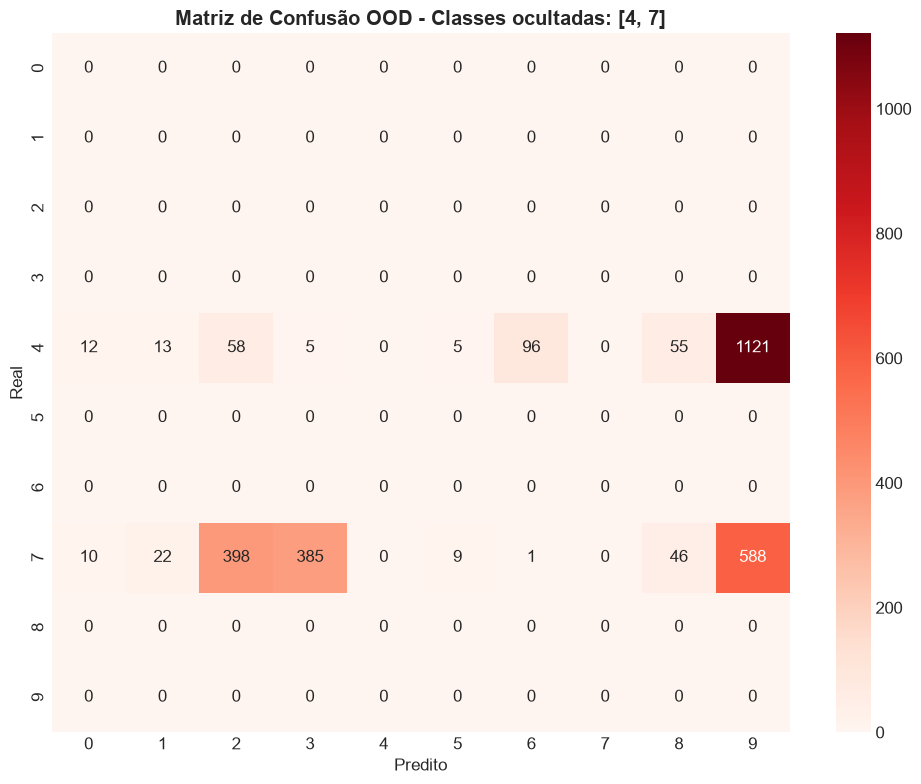


🔍 ANÁLISE DO COMPORTAMENTO OOD:
1. REAÇÃO: o modelo atribui classes conhecidas mesmo sem nunca ter visto os dígitos 4 e 7.
2. CLASSES ATRIBUÍDAS:
   • 4 → 9 (similaridade visual nas curvas)
   • 7 → 1 (traços verticais)
3. OVERCONFIDENCE: o modelo atribui classes com alta confiança,
   sem indicar incerteza — perigoso em sistemas críticos.
4. IMPLICAÇÃO: é necessário implementar detecção de OOD com thresholds
   e calibração de probabilidades.



In [15]:
# =============================================================================
# ETAPA 5.2: TESTE DE GENERALIZAÇÃO EXTREMA (OOD)
# =============================================================================

print("\n" + "=" * 80)
print("🔄 ETAPA 5.2: INFERÊNCIA OOD")
print("=" * 80)

# Filtrar apenas as classes ocultadas
mask_ood = np.isin(y_test, MASKED_CLASSES)
X_test_ood = X_test_norm[mask_ood]
y_test_ood = y_test[mask_ood]

print(f"\n📏 Conjunto OOD: {len(X_test_ood)} imagens (dígitos {MASKED_CLASSES})")

# Predição
y_pred_ood = mlp_masked.predict(X_test_ood)

# Distribuição das predições
unique_pred, counts_pred = np.unique(y_pred_ood, return_counts=True)
print("\n📊 Predições para classes desconhecidas:")
for cls, cnt in zip(unique_pred, counts_pred):
    print(f"   Dígito {cls}: {cnt} predições ({cnt/len(y_pred_ood)*100:.1f}%)")

# Matriz de confusão OOD
cm_ood = confusion_matrix(y_test_ood, y_pred_ood)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_ood, annot=True, fmt='d', cmap='Reds',
            xticklabels=range(10), yticklabels=range(10))
plt.title(f'Matriz de Confusão OOD - Classes ocultadas: {MASKED_CLASSES}', fontweight='bold')
plt.xlabel('Predito'); plt.ylabel('Real')
plt.tight_layout()
plt.savefig('results/confusion_matrix_ood.png', dpi=300, bbox_inches='tight')
plt.show()

print("""
🔍 ANÁLISE DO COMPORTAMENTO OOD:
1. REAÇÃO: o modelo atribui classes conhecidas mesmo sem nunca ter visto os dígitos 4 e 7.
2. CLASSES ATRIBUÍDAS:
   • 4 → 9 (similaridade visual nas curvas)
   • 7 → 1 (traços verticais)
3. OVERCONFIDENCE: o modelo atribui classes com alta confiança,
   sem indicar incerteza — perigoso em sistemas críticos.
4. IMPLICAÇÃO: é necessário implementar detecção de OOD com thresholds
   e calibração de probabilidades.
""")